# 02 Train Pipeline

Trains the composer classifier and presents the cross validation results. The model
(`src/modeling/model.py`) is a hybrid: a CNN reads the piano roll crop like an image
(three conv blocks with 16, 32, and 64 channels), an LSTM reads the CNN output left to
right as a sequence over time, and the LSTM's final hidden state is concatenated with the
37 handcrafted music theory features before the dense head maps to 4 composer logits.

All hyperparameters are fixed in `src/modeling/config.py` at the winners of a greedy
hyperparameter sweep (learning rate 1e-3 and the 16/32/64 CNN; the sweep protocol and
every candidate's score are in the decisions log). Training is stratified 5 fold cross
validation by song: each fold's model trains on one random 30 second crop per song per
epoch with class weighted cross entropy, and is scored on its held out fold by windowing
each song and averaging the window probabilities into one song prediction. The held out
fold drives both early stopping and the reported metrics, so the estimates are mildly
optimistic (disclosed in the decisions log).

Training runs only when `experiments/final/` does not exist yet, so rerunning this
notebook never overwrites the canonical run. Change `RUN_NAME` to train from scratch
(roughly an hour on this machine).

In [1]:
import json
import subprocess
from pathlib import Path

import pandas as pd

PYTHON = "/opt/miniconda3/envs/composer-classification/bin/python"
REPO_ROOT = Path.cwd().parent
RUN_NAME = "final"
RUN_DIR = REPO_ROOT / "experiments" / RUN_NAME

if (RUN_DIR / "summary.json").exists():
    print(f"skipping training: {RUN_DIR.relative_to(REPO_ROOT)} exists")
else:
    print(f"training all 5 folds as {RUN_NAME} (roughly an hour) ...")
    result = subprocess.run([PYTHON, "-m", "src.modeling.train", RUN_NAME],
                            cwd=REPO_ROOT, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"training failed:\n{result.stderr}")
    print(result.stdout[-1500:])  # the tail: last fold and the summary line

skipping training: experiments/final exists


## Cross validation results

`summary.json` records each fold's scores at its best epoch. The headline number for the
report is the mean macro-F1 across folds, with the standard deviation showing how much
the folds disagree.

In [2]:
summary = json.loads((RUN_DIR / "summary.json").read_text())

folds = pd.DataFrame(summary["folds"]).T
folds.index.name = "fold"
folds["epoch"] = folds["epoch"].astype(int)
print(f"macro-F1 {summary['mean_macro_f1']:.4f} +/- {summary['std_macro_f1']:.4f} "
      f"over 5 folds, mean balanced accuracy {summary['mean_balanced_acc']:.4f}")
folds.round(4)

macro-F1 0.8120 +/- 0.0214 over 5 folds, mean balanced accuracy 0.8113


,macro_f1,balanced_acc,epoch
fold,,,
0,0.8499,0.8516,47
1,0.8125,0.8068,43
2,0.8149,0.8104,37
3,0.7904,0.8014,10
4,0.7925,0.7862,17


## Training curves

Each fold logged one `metrics.csv` row per epoch. A curve ends where early stopping
fired (10 epochs with no new best), and the dot marks the best epoch, whose weights are
what `best.pt` saved and what the scores above describe.

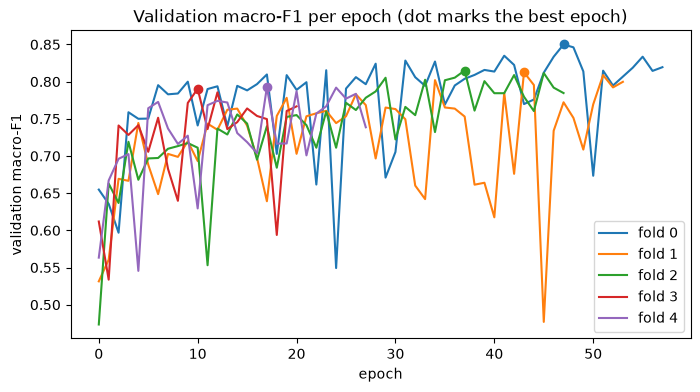

In [3]:
import matplotlib.pyplot as plt

metrics = {k: pd.read_csv(RUN_DIR / f"fold{k}" / "metrics.csv") for k in range(5)}

fig, ax = plt.subplots(figsize=(8, 4))
for k, m in metrics.items():
    line, = ax.plot(m["epoch"], m["val_macro_f1"], label=f"fold {k}")
    best = m["val_macro_f1"].idxmax()
    ax.plot(m.loc[best, "epoch"], m.loc[best, "val_macro_f1"], "o",
            color=line.get_color())
ax.set_xlabel("epoch")
ax.set_ylabel("validation macro-F1")
ax.set_title("Validation macro-F1 per epoch (dot marks the best epoch)")
ax.legend()
plt.show()

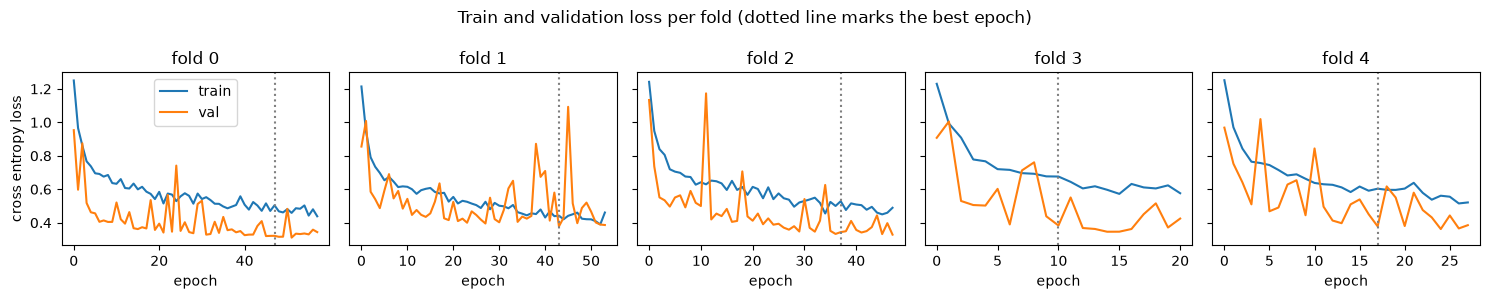

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
for k, ax in enumerate(axes):
    m = metrics[k]
    ax.plot(m["epoch"], m["train_loss"], label="train")
    ax.plot(m["epoch"], m["val_loss"], label="val")
    best = m["val_macro_f1"].idxmax()
    ax.axvline(m.loc[best, "epoch"], color="gray", linestyle=":")
    ax.set_title(f"fold {k}")
    ax.set_xlabel("epoch")
axes[0].set_ylabel("cross entropy loss")
axes[0].legend()
fig.suptitle("Train and validation loss per fold (dotted line marks the best epoch)")
fig.tight_layout()
plt.show()

## Takeaways

- The final model scores macro-F1 0.8120 +/- 0.0214 across the 5 folds (mean balanced
  accuracy 0.8113). Fold 0 is the friendliest at 0.8499 while folds 3 and 4 sit near 0.79,
  a 6 point spread across resamples, so no single fold number should be quoted alone.
- Best epochs range from 10 (fold 3) to 47 (fold 0), so early stopping earns its keep: any
  fixed epoch budget would have overshot some folds and undershot others.
- The validation macro-F1 curves are noisy from epoch to epoch because every training epoch
  sees a different random crop of each song. Patience 10 plus checkpointing the best epoch
  is what makes that noise harmless.
- Validation loss sitting below train loss in every fold is expected here, not a sign of a
  bug: train loss is measured on random 30 second crops with dropout active and class
  weights applied, while validation scores whole songs by averaging window probabilities,
  an easier and unweighted task. Neither loss trends upward, so there is no runaway
  overfitting at the chosen stopping points.